Chunk 1: Data Preprocessing

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, RFE
from sklearn.ensemble import RandomForestClassifier

# Load and preprocess the supermarket dataset
df = pd.read_csv('/content/drive/MyDrive/supermarket_sales.csv')

# Define thresholds for categorizing rating
def categorize_rating(rating):
    if rating < 5.0:
        return 'Poor'
    elif 5.0 <= rating < 7.0:
        return 'Average'
    elif 7.0 <= rating < 9.0:
        return 'Good'
    else:
        return 'Excellent'

# Create Rating_Category column
df['Rating_Category'] = df['Rating'].apply(categorize_rating)

# Drop irrelevant columns
columns_to_drop = ['Rating', 'Invoice ID', 'Date', 'gross margin percentage']
if 'Time' in df.columns:
    df['Time_Category'] = df['Time'].apply(lambda time: 'Morning' if 5 <= int(time.split(':')[0]) < 12 else
                                                        'Afternoon' if 12 <= int(time.split(':')[0]) < 17 else
                                                        'Evening' if 17 <= int(time.split(':')[0]) < 21 else
                                                        'Night')
    columns_to_drop.append('Time')

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Convert categorical columns into numerical columns
le = LabelEncoder()
cat_columns = ['Branch', 'City', 'Product line', 'Payment', 'Customer type', 'Time_Category', 'Gender', 'Rating_Category']
for col in cat_columns:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# Normalize the data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

# Split data into features and target variable
rating = df['Rating_Category']
X = df.drop('Rating_Category', axis=1)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, rating, test_size=0.2, random_state=42)



In [ ]:
# Define and run Non-Weighted KNN for different distance metrics
def run_non_weighted_knn(X_train, X_test, y_train, y_test):
    metrics = ['euclidean', 'manhattan', 'minkowski']
    results = {}

    for metric in metrics:
        k_range = range(1, 21)
        accuracy = []
        for k in k_range:
            if metric == 'minkowski':
                model = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3)  # Set p=3 for Minkowski
            else:
                model = KNeighborsClassifier(n_neighbors=k, metric=metric)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy.append(f1_score(y_test, y_pred, average='weighted'))

        results[metric] = accuracy

    return results

# Run Non-Weighted KNN for the dataset
results_non_weighted = run_non_weighted_knn(X_train, X_test, y_train, y_test)


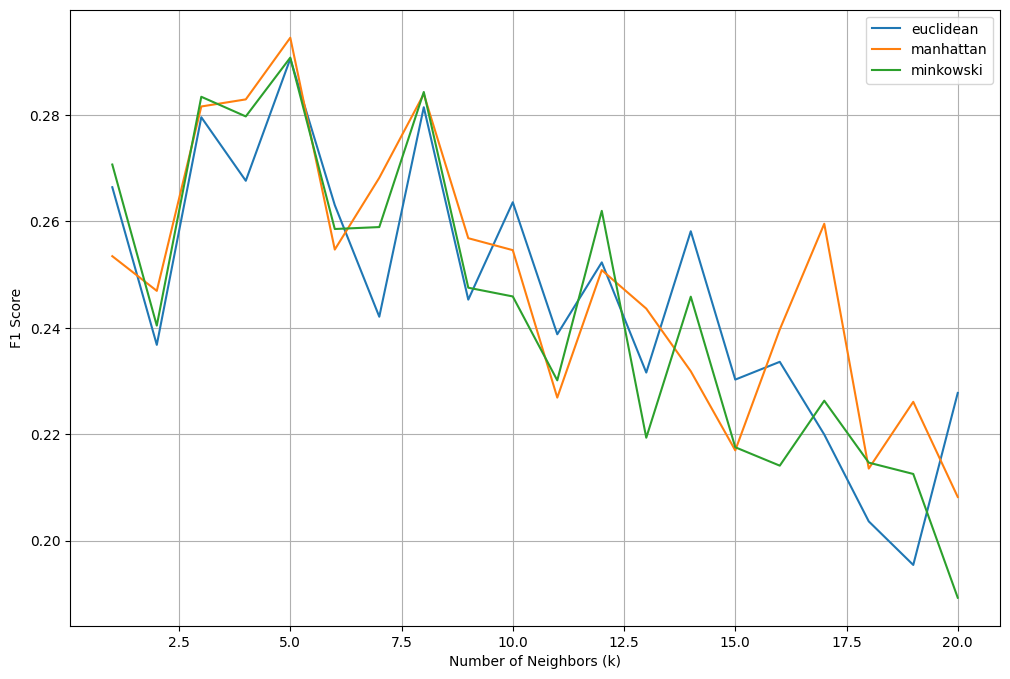

Best k for euclidean: 5 with F1 Score: 0.2906
Best k for manhattan: 5 with F1 Score: 0.2945
Best k for minkowski: 5 with F1 Score: 0.2908


In [ ]:
# Plot performance of Non-Weighted KNN for different distance metrics
def plot_knn_performance(results):
    plt.figure(figsize=(12, 8))

    best_k_scores = {}  # Dictionary to hold best k and scores

    for metric, scores in results.items():
        k_values = range(1, 21)
        plt.plot(k_values, scores, label=metric)

        # Find the best k value and F1 score
        best_k = k_values[np.argmax(scores)]
        best_score = max(scores)

        # Store the best k and F1 score
        best_k_scores[metric] = (best_k, best_score)

        # # Plot the best k value and its F1 score
        # plt.scatter(best_k, best_score, label=f'Best k={best_k} ({metric})',
        #             color='red', zorder=5, edgecolor='black')
        # plt.text(best_k, best_score, f'k={best_k}', color='red',
        #          verticalalignment='bottom', horizontalalignment='right')

    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print best k and F1 scores for each metric
    for metric, (best_k, best_score) in best_k_scores.items():
        print(f'Best k for {metric}: {best_k} with F1 Score: {best_score:.4f}')

# Plot the results
plot_knn_performance(results_non_weighted)


weighted

{'euclidean': [0.26640839135748484, 0.23678111875781757, 0.27956046595482353, 0.26761481481481486, 0.290558105872622, 0.2630439988861042, 0.24206751481635844, 0.28144075522296386, 0.2452811369414742, 0.2635825252463294, 0.23876515366020434, 0.25228202347029444, 0.23157448631804464, 0.25812768840454364, 0.23025115449377329, 0.23359221791506332, 0.21992363140139015, 0.20360528603303168, 0.19541729174891434, 0.22774259511595343], 'manhattan': [0.2534457952597392, 0.24692895339954163, 0.28157874017161527, 0.2829125795534163, 0.2945021770528015, 0.25468857649442755, 0.26817825739408474, 0.28391938997821353, 0.25682394295516947, 0.25457872820774274, 0.22686621349664826, 0.25082799145299145, 0.24359199134199133, 0.2318236553455795, 0.21694814124362047, 0.23966523078920818, 0.25953695081665307, 0.21352671978235524, 0.22607530120481928, 0.2081894534995206], 'minkowski': [0.2706699882520598, 0.24039893850525604, 0.283404051303646, 0.2797110196875837, 0.2907625402719083, 0.25855264164427133, 0.25

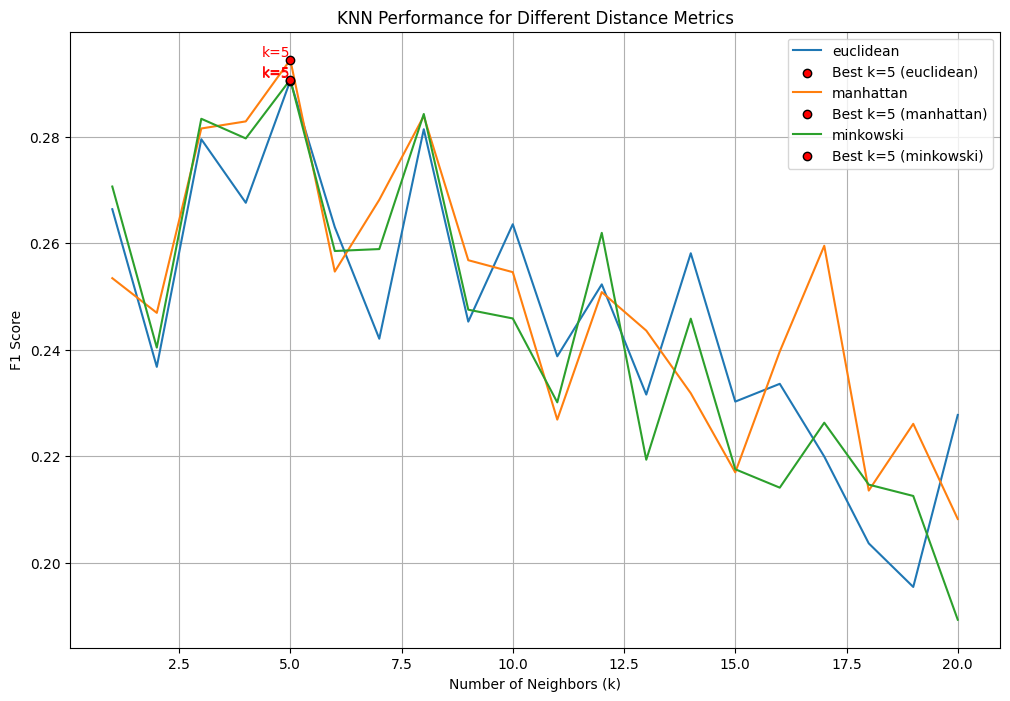

Best k for euclidean: 5 with F1 Score: 0.2906
Best k for manhattan: 5 with F1 Score: 0.2945
Best k for minkowski: 5 with F1 Score: 0.2908


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

def weighted_distance(X, Y, weights, metric='euclidean', p=3):
    X = np.array(X)
    Y = np.array(Y)
    weights = np.array(weights)

    if metric == 'euclidean':
        return np.sqrt(np.sum(weights * (X - Y) ** 2, axis=1))
    elif metric == 'manhattan':
        return np.sum(weights * np.abs(X - Y), axis=1)
    elif metric == 'minkowski':
        return np.power(np.sum(weights * np.abs(X - Y) ** p, axis=1), 1 / p)
    else:
        raise ValueError("Unsupported metric")

class WeightedKNNClassifier(KNeighborsClassifier):
    def __init__(self, n_neighbors=5, metric='euclidean', weights='uniform', p=3, feature_weights=None):
        super().__init__(n_neighbors=n_neighbors, metric=metric, weights=weights, p=p)
        self.feature_weights = np.array(feature_weights) if feature_weights is not None else np.ones(1)

    def _get_weights(self, dist, weights):
        if weights in ['uniform', 'distance']:
            return super()._get_weights(dist, weights)
        return weights

    def _compute_distances(self, X):
        X = np.array(X)
        distances = []
        for x in X:
            x = np.reshape(x, (1, -1))  # Ensure correct shape
            dist = weighted_distance(self._fit_X, x, self.feature_weights, self.metric, self.p)
            distances.append(dist)
        return np.array(distances)

    def fit(self, X, y):
        self._fit_X = np.array(X, dtype=np.float64)
        self._fit_y = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        distances = self._compute_distances(X)
        indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]
        votes = self._fit_y[indices]
        if self.weights == 'distance':
            weights = self._get_weights(distances[np.arange(distances.shape[0])[:, None], indices], self.weights)
            y_pred = np.array([np.bincount(v, weights=w, minlength=len(np.unique(self._fit_y))).argmax() for v, w in zip(votes, weights)])
        else:
            y_pred = np.array([np.bincount(v).argmax() for v in votes])
        return y_pred

def run_weighted_knn_without_feature_extraction(X_train, X_test, y_train, y_test, feature_weights, dataset_name):
    metrics = ['euclidean', 'manhattan', 'minkowski']
    k_range = range(1, 21)
    results = {metric: [] for metric in metrics}

    for metric in metrics:
        for k in k_range:
            model = WeightedKNNClassifier(n_neighbors=k, metric=metric, feature_weights=feature_weights)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            results[metric].append(f1_score(y_test, y_pred, average='weighted'))

    return results

def plot_knn_performance(results):
    plt.figure(figsize=(12, 8))

    best_k_scores = {}  # Dictionary to hold best k and scores

    for metric, scores in results.items():
        k_values = range(1, 21)
        plt.plot(k_values, scores, label=metric)

        # Find the best k value and F1 score
        best_k = k_values[np.argmax(scores)]
        best_score = max(scores)

        # Store the best k and F1 score
        best_k_scores[metric] = (best_k, best_score)

        # Plot the best k value and its F1 score
        plt.scatter(best_k, best_score, label=f'Best k={best_k} ({metric})',
                    color='red', zorder=5, edgecolor='black')
        plt.text(best_k, best_score, f'k={best_k}', color='red',
                 verticalalignment='bottom', horizontalalignment='right')

    plt.title('KNN Performance for Different Distance Metrics')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print best k and F1 scores for each metric
    for metric, (best_k, best_score) in best_k_scores.items():
        print(f'Best k for {metric}: {best_k} with F1 Score: {best_score:.4f}')

# Example usage:
# feature_weights should be a 1D array with the same length as the number of features in X_train
# For demonstration, let's assume feature_weights is an array of ones with the same length as the number of features
feature_weights = np.ones(X_train.shape[1])

# Run Weighted KNN for the dataset
results_weighted = run_weighted_knn_without_feature_extraction(X_train, X_test, y_train, y_test, feature_weights, 'Supermarket')
print(results_weighted)

# Plot the results
plot_knn_performance(results_weighted)



Chunk 3: Feature Extraction and **Weighting**

Evaluating feature extraction method: VarianceThreshold


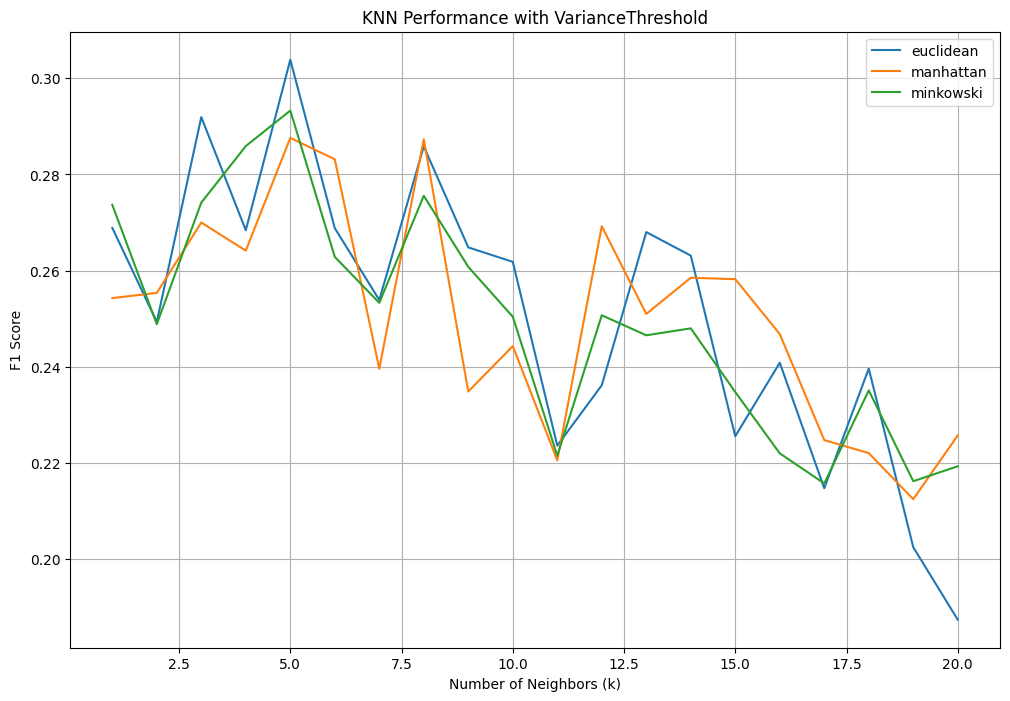

Best k for euclidean: 5 with F1 Score: 0.3039
Best k for manhattan: 5 with F1 Score: 0.2876
Best k for minkowski: 5 with F1 Score: 0.2933
Evaluating feature extraction method: SelectKBest


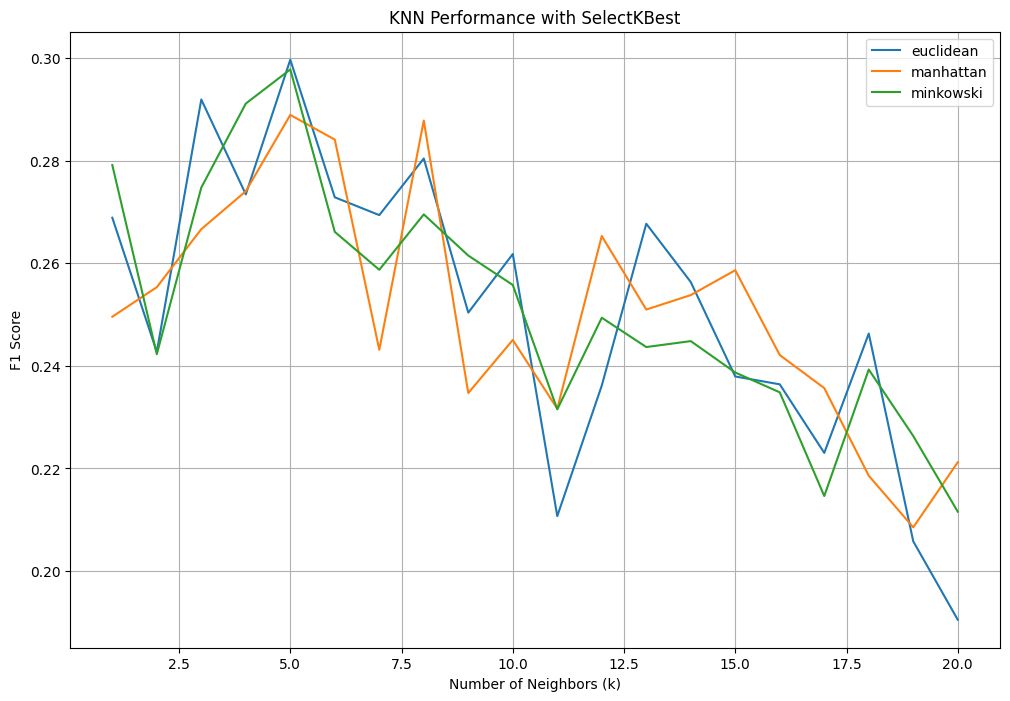

Best k for euclidean: 5 with F1 Score: 0.2997
Best k for manhattan: 5 with F1 Score: 0.2889
Best k for minkowski: 5 with F1 Score: 0.2978
Evaluating feature extraction method: RFE


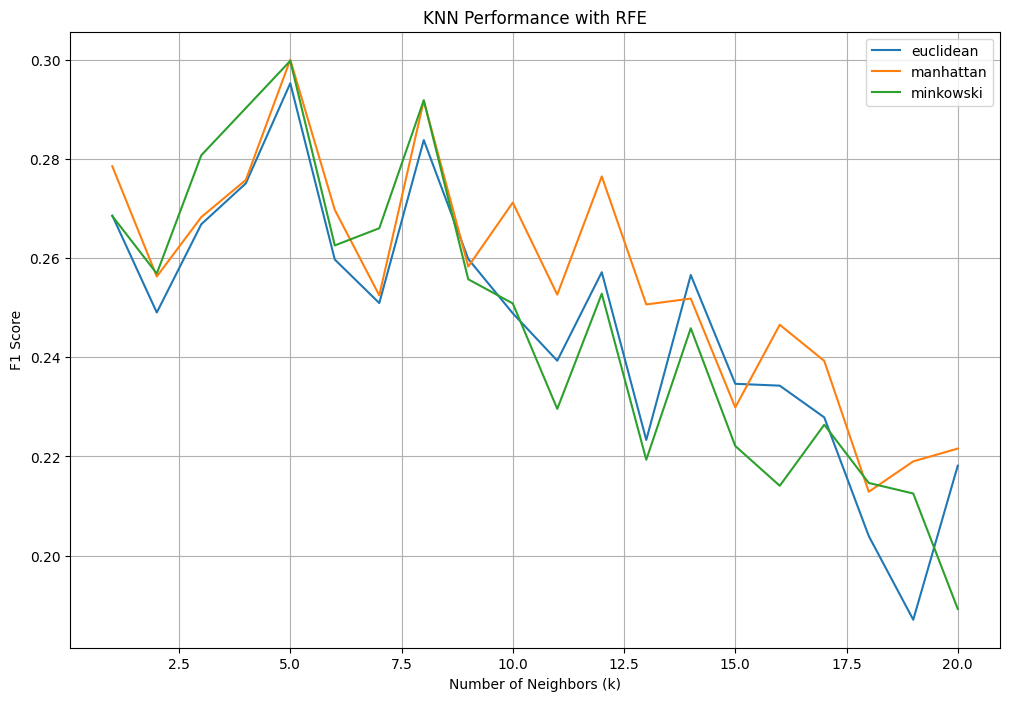

Best k for euclidean: 5 with F1 Score: 0.2952
Best k for manhattan: 5 with F1 Score: 0.3000
Best k for minkowski: 5 with F1 Score: 0.2997
Evaluating feature extraction method: RandomForest


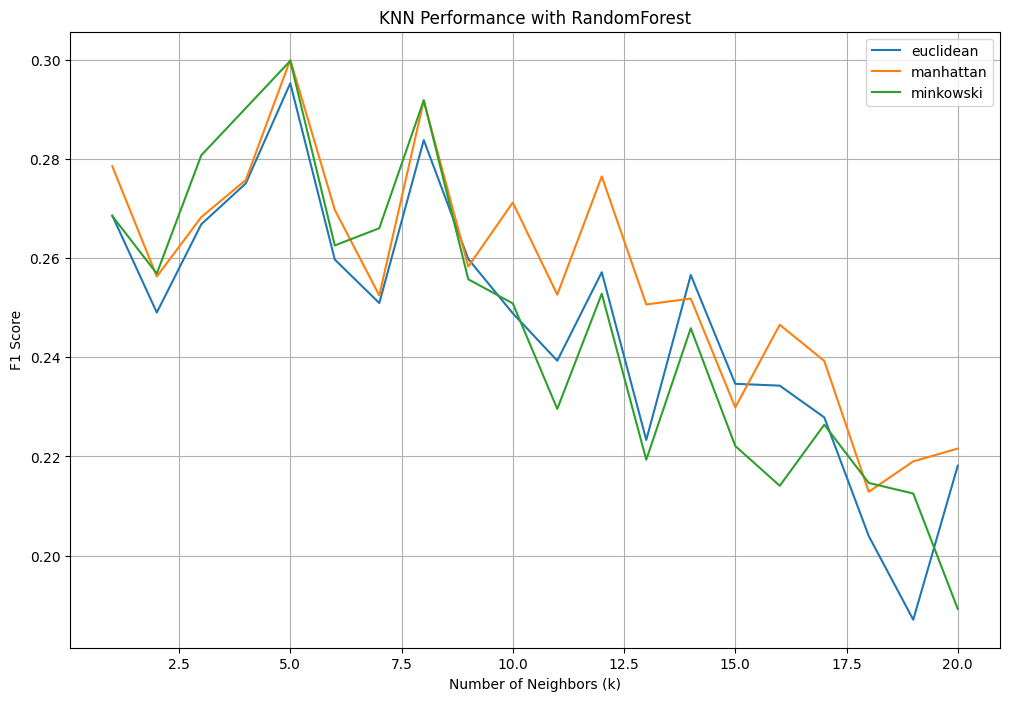

Best k for euclidean: 5 with F1 Score: 0.2952
Best k for manhattan: 5 with F1 Score: 0.3000
Best k for minkowski: 5 with F1 Score: 0.2997


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, RFE
from sklearn.ensemble import RandomForestClassifier

def extract_and_weight_features(X_train, y_train, initial_threshold=0.16, min_threshold=0.01, step=0.01):
    threshold = initial_threshold
    feature_selected = False

    while not feature_selected and threshold >= min_threshold:
        try:
            sel = VarianceThreshold(threshold=threshold)
            X_train_var = sel.fit_transform(X_train)
            if X_train_var.shape[1] > 0:
                feature_selected = True
        except ValueError:
            threshold -= step

    if not feature_selected:
        raise ValueError("No feature in X meets the minimum variance threshold")

    # Univariate Feature Selection
    skb = SelectKBest(score_func=chi2, k='all')  # Select all features for analysis
    X_train_uni = skb.fit_transform(X_train, y_train)

    # Recursive Feature Elimination (RFE)
    rfe = RFE(estimator=RandomForestClassifier(), n_features_to_select=4)
    X_train_rfe = rfe.fit_transform(X_train, y_train)

    # Tree-based Feature Selection
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_features = indices[:4]

    # Combine the results to find common top features
    all_features = np.concatenate((sel.get_support(indices=True), skb.get_support(indices=True), rfe.get_support(indices=True), top_features))
    unique, counts = np.unique(all_features, return_counts=True)
    top_common_features = unique[np.argsort(counts)[::-1][:4]]

    # Assign weights to features
    feature_weights = np.ones(X_train.shape[1])
    feature_weights[top_common_features] = 5  # Assign higher weight to top features

    return feature_weights, {
        'VarianceThreshold': sel.get_support(indices=True),
        'SelectKBest': skb.get_support(indices=True),
        'RFE': rfe.get_support(indices=True),
        'RandomForest': top_features
    }

def weighted_distance(X, Y, weights, metric='euclidean', p=3):
    if metric == 'euclidean':
        return np.sqrt(np.sum(weights * (X - Y) ** 2, axis=1))
    elif metric == 'manhattan':
        return np.sum(weights * np.abs(X - Y), axis=1)
    elif metric == 'minkowski':
        return np.power(np.sum(weights * np.abs(X - Y) ** p, axis=1), 1 / p)
    else:
        raise ValueError("Unsupported metric")

class WeightedKNNClassifier(KNeighborsClassifier):
    def __init__(self, n_neighbors=5, metric='euclidean', weights='uniform', p=3, feature_weights=None):
        super().__init__(n_neighbors=n_neighbors, metric=metric, weights=weights, p=p)
        self.feature_weights = np.array(feature_weights, dtype=np.float64) if feature_weights is not None else np.ones(X_train.shape[1], dtype=np.float64)

    def _get_weights(self, dist, weights):
        if weights in ['uniform', 'distance']:
            return super()._get_weights(dist, weights)
        return weights

    def _compute_distances(self, X):
        distances = []
        for x in X:
            dist = weighted_distance(self._fit_X, x, self.feature_weights, self.metric, self.p)
            distances.append(dist)
        return np.array(distances)

    def fit(self, X, y):
        self._fit_X = np.array(X, dtype=np.float64)
        self._fit_y = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        distances = self._compute_distances(X)
        indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]
        votes = self._fit_y[indices]
        if self.weights == 'distance':
            weights = self._get_weights(distances[np.arange(distances.shape[0])[:, None], indices], self.weights)
            y_pred = np.array([np.bincount(v, weights=w, minlength=len(np.unique(self._fit_y))).argmax() for v, w in zip(votes, weights)])
        else:
            y_pred = np.array([np.bincount(v).argmax() for v in votes])
        return y_pred

def run_weighted_knn_with_feature_extraction(X_train, X_test, y_train, y_test, feature_weights, feature_selection_method):
    metrics = ['euclidean', 'manhattan', 'minkowski']
    k_range = range(1, 21)
    results = {metric: [] for metric in metrics}

    for metric in metrics:
        for k in k_range:
            model = WeightedKNNClassifier(n_neighbors=k, metric=metric, feature_weights=feature_weights)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            results[metric].append(f1_score(y_test, y_pred, average='weighted'))

    return results

def plot_knn_performance(results, feature_selection_method):
    plt.figure(figsize=(12, 8))

    for metric, scores in results.items():
        k_values = range(1, 21)
        plt.plot(k_values, scores, label=metric)

    plt.title(f'KNN Performance with {feature_selection_method}')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    best_k_scores = {}
    for metric, scores in results.items():
        k_values = range(1, 21)
        best_k = k_values[np.argmax(scores)]
        best_score = max(scores)
        best_k_scores[metric] = (best_k, best_score)
        print(f'Best k for {metric}: {best_k} with F1 Score: {best_score:.4f}')

# Example usage
# Ensure feature_weights is an array with the same length as the number of features in X_train
feature_weights, feature_scores = extract_and_weight_features(X_train, y_train, initial_threshold=0.16, min_threshold=0.01, step=0.01)

# Run Weighted KNN for each feature extraction method and plot the results
feature_selection_methods = ['VarianceThreshold', 'SelectKBest', 'RFE', 'RandomForest']
for method in feature_selection_methods:
    print(f"Evaluating feature extraction method: {method}")
    # Generate feature_weights and results for each method
    feature_weights, _ = extract_and_weight_features(X_train, y_train, initial_threshold=0.16, min_threshold=0.01, step=0.01)
    results_weighted_ext = run_weighted_knn_with_feature_extraction(X_train, X_test, y_train, y_test, feature_weights, method)
    plot_knn_performance(results_weighted_ext, method)


Chunk 4: Visualize Feature Selection

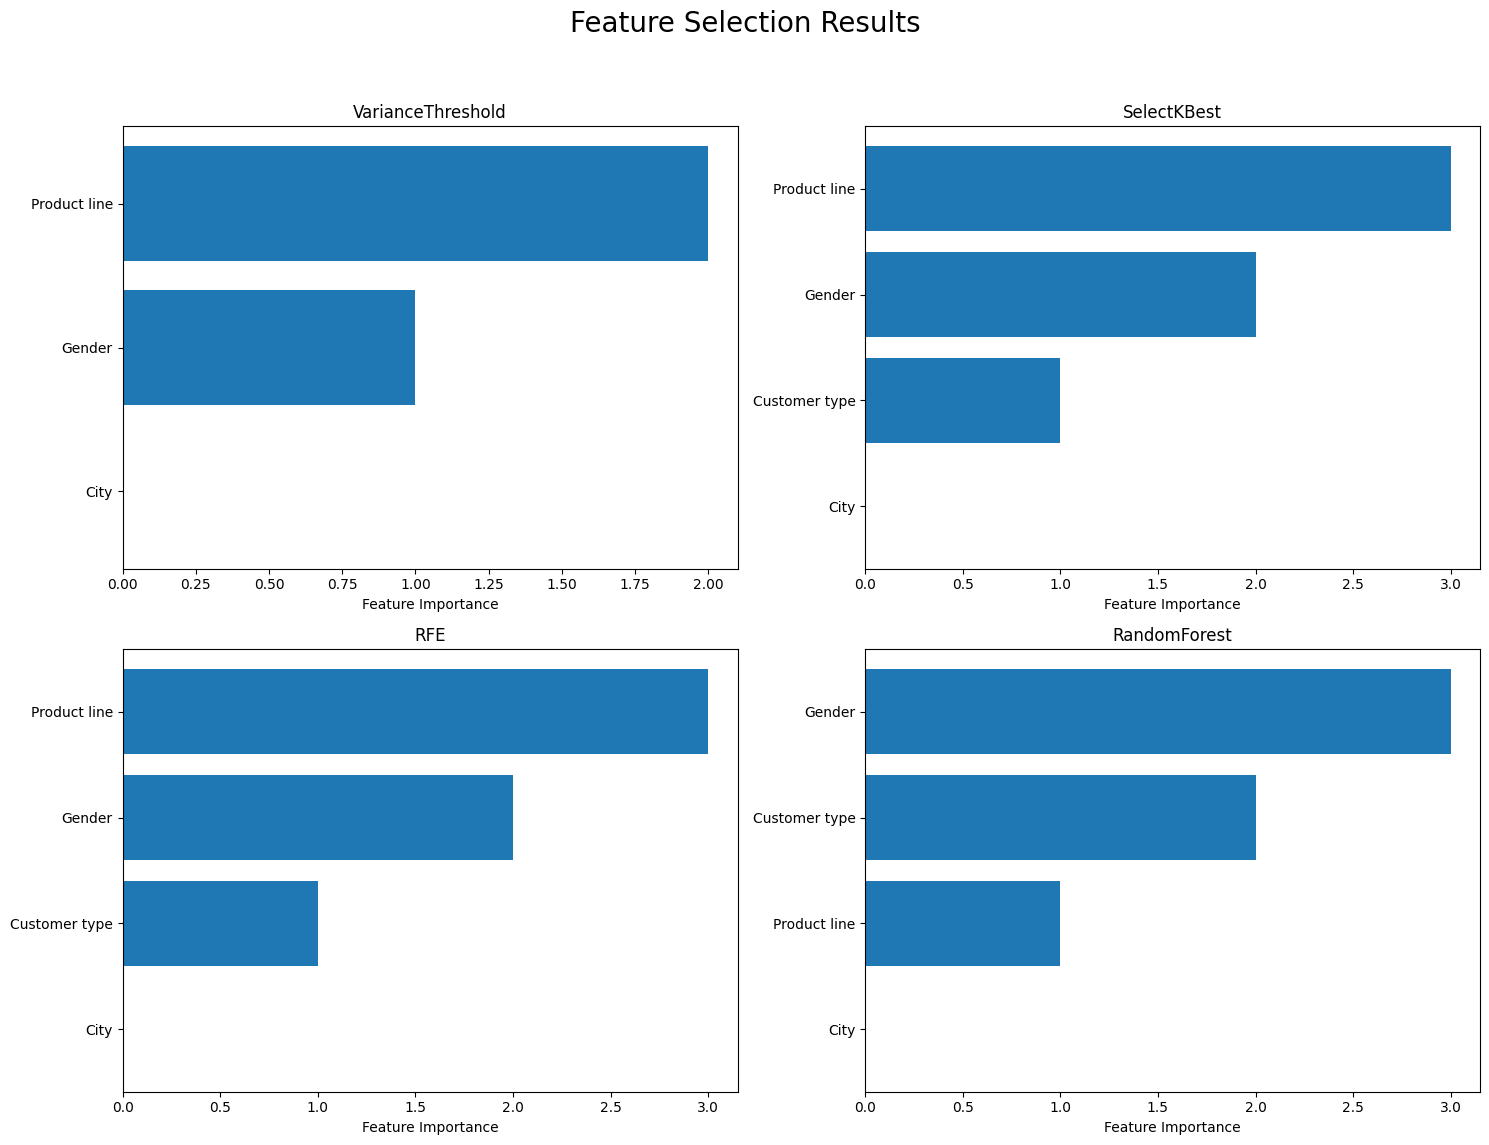

In [ ]:
# Visualize feature selection
def plot_feature_selection(feature_scores, feature_names):
    fig, ax = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Feature Selection Results', fontsize=20)

    for idx, (method, indices) in enumerate(feature_scores.items()):
        ax = plt.subplot(2, 2, idx+1)
        features = np.array(feature_names)[indices]
        ax.barh(features, np.arange(len(features)))
        ax.set_yticks(features)
        ax.set_title(method)
        ax.set_xlabel('Feature Importance')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot feature selection results
plot_feature_selection(feature_scores, X.columns)


Chunk 4: Custom Distance Function and KNN Classifier

{'euclidean': [0.26855115995115997, 0.24900518520818454, 0.26679849374448616, 0.27503433550695366, 0.29522600492837364, 0.2596868754980602, 0.25091628510793773, 0.2837633115309048, 0.2597983389957312, 0.24884951618099607, 0.23929540771782787, 0.257132344077006, 0.2233115760415532, 0.2565687784074374, 0.2346377182420229, 0.23426142942153075, 0.22786618632509043, 0.2039500472366556, 0.18707450980392157, 0.21811355311355313], 'manhattan': [0.2784907527527801, 0.25625909354032633, 0.2682414639160427, 0.27571785754158756, 0.2999685278701864, 0.26970538720538717, 0.25245888066236766, 0.2917119914003337, 0.2582759085502841, 0.271167747837658, 0.25260887086976064, 0.27644499797794664, 0.2506297431491675, 0.2518127883981543, 0.2298753387533875, 0.24653477785158842, 0.23924969861362266, 0.21287037296751998, 0.218994338994339, 0.2215785803514896], 'minkowski': [0.2684586652736059, 0.2568577830620084, 0.2807077701088856, 0.29021327956475074, 0.2997446808510638, 0.26252854525872915, 0.2659976123656

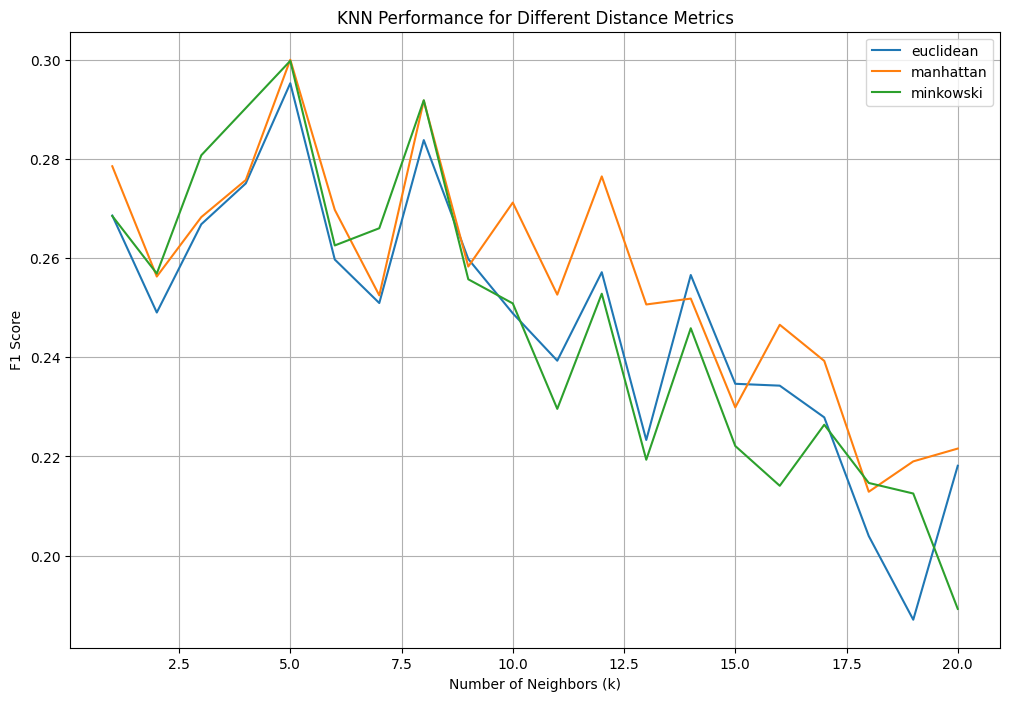

Best k for euclidean: 5 with F1 Score: 0.2952
Best k for manhattan: 5 with F1 Score: 0.3000
Best k for minkowski: 5 with F1 Score: 0.2997


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

def weighted_distance(X, Y, weights, metric='euclidean', p=3):
    if metric == 'euclidean':
        return np.sqrt(np.sum(weights * (X - Y) ** 2, axis=1))
    elif metric == 'manhattan':
        return np.sum(weights * np.abs(X - Y), axis=1)
    elif metric == 'minkowski':
        return np.power(np.sum(weights * np.abs(X - Y) ** p, axis=1), 1 / p)
    else:
        raise ValueError("Unsupported metric")

class WeightedKNNClassifier(KNeighborsClassifier):
    def __init__(self, n_neighbors=5, metric='euclidean', weights='uniform', p=3, feature_weights=None):
        super().__init__(n_neighbors=n_neighbors, metric=metric, weights=weights, p=p)
        self.feature_weights = np.array(feature_weights, dtype=np.float64) if feature_weights is not None else np.ones(X_train.shape[1], dtype=np.float64)

    def _get_weights(self, dist, weights):
        if weights in ['uniform', 'distance']:
            return super()._get_weights(dist, weights)
        return weights

    def _compute_distances(self, X):
        distances = []
        for x in X:
            dist = weighted_distance(self._fit_X, x, self.feature_weights, self.metric, self.p)
            distances.append(dist)
        return np.array(distances)

    def fit(self, X, y):
        self._fit_X = np.array(X, dtype=np.float64)
        self._fit_y = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        distances = self._compute_distances(X)
        indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]
        votes = self._fit_y[indices]
        if self.weights == 'distance':
            weights = self._get_weights(distances[np.arange(distances.shape[0])[:, None], indices], self.weights)
            y_pred = np.array([np.bincount(v, weights=w, minlength=len(np.unique(self._fit_y))).argmax() for v, w in zip(votes, weights)])
        else:
            y_pred = np.array([np.bincount(v).argmax() for v in votes])
        return y_pred

def run_weighted_knn_with_feature_extraction(X_train, X_test, y_train, y_test, feature_weights, dataset_name):
    metrics = ['euclidean', 'manhattan', 'minkowski']
    k_range = range(1, 21)
    results = {metric: [] for metric in metrics}

    for metric in metrics:
        for k in k_range:
            model = WeightedKNNClassifier(n_neighbors=k, metric=metric, feature_weights=feature_weights)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            results[metric].append(f1_score(y_test, y_pred, average='weighted'))

    return results

def plot_knn_performance(results):
    plt.figure(figsize=(12, 8))

    best_k_scores = {}  # Dictionary to hold best k and scores

    for metric, scores in results.items():
        k_values = range(1, 21)
        plt.plot(k_values, scores, label=metric)

        # Find the best k value and F1 score
        best_k = k_values[np.argmax(scores)]
        best_score = max(scores)

        # Store the best k and F1 score
        best_k_scores[metric] = (best_k, best_score)

        # # Plot the best k value and its F1 score
        # plt.scatter(best_k, best_score, label=f'Best k={best_k} ({metric})',
        #             color='red', zorder=5, edgecolor='black')
        # plt.text(best_k, best_score, f'k={best_k}', color='red',
        #          verticalalignment='bottom', horizontalalignment='right')

    plt.title('KNN Performance for Different Distance Metrics')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print best k and F1 scores for each metric
    for metric, (best_k, best_score) in best_k_scores.items():
        print(f'Best k for {metric}: {best_k} with F1 Score: {best_score:.4f}')

# Run Weighted KNN for the dataset
results_weighted_ext = run_weighted_knn_with_feature_extraction(X_train, X_test, y_train, y_test, feature_weights, 'Supermarket')
print(results_weighted_ext)

# Plot the results
plot_knn_performance(results_weighted_ext)


Chunk 5: Run Weighted KNN with Feature Extraction

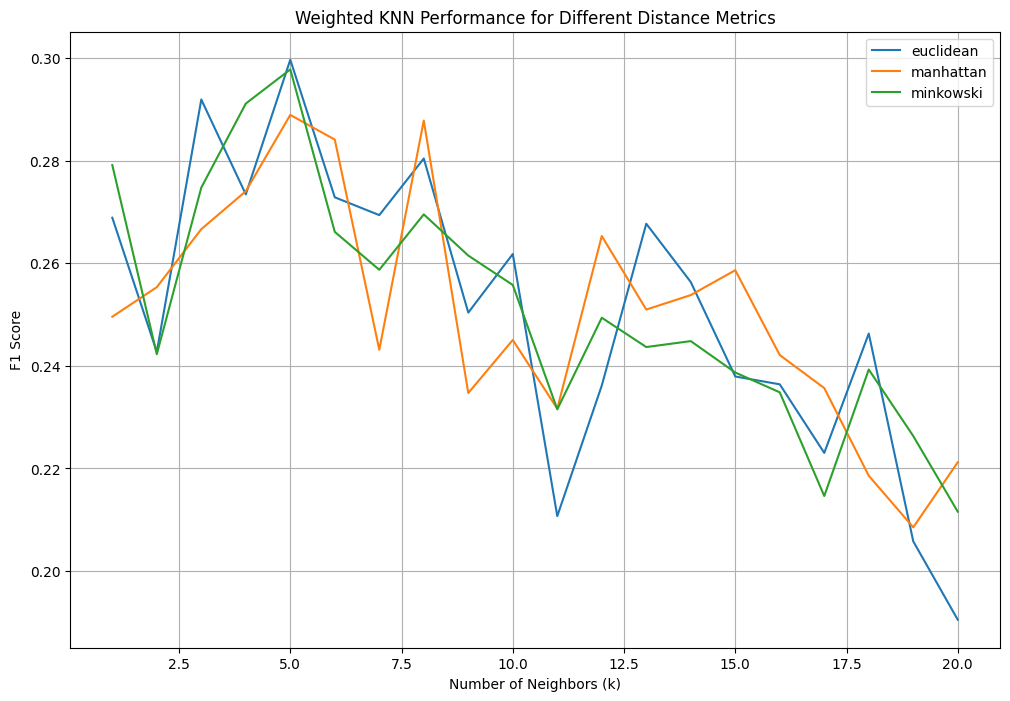

In [ ]:
# Plot performance of Weighted KNN for different distance metrics
def plot_weighted_knn_performance(results):
    plt.figure(figsize=(12, 8))

    for metric, scores in results.items():
        plt.plot(range(1, 21), scores, label=metric)

    plt.title('Weighted KNN Performance for Different Distance Metrics')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the results
plot_weighted_knn_performance(results_weighted_ext)


#Whole code corrrected